# Replicating Hopenhayn (1992)
Below is the replication of Hopenhayn (1992).

In [12]:
using Parameters, QuantEcon, LinearAlgebra, Roots, Printf, DataFrames, Plots
include("functions/ModelInfrastructure.jl")
include("functions/Functions.jl")
p̂   =fnSolveSteadyState(UsedParameters,Endo)

1.4816388591508873

## Question 1: Baseline equilibrium computation 
Note the discrepancies in the aggregate labour condition. 

In [10]:
include("scripts/ResultsSummary.jl")
fnPrintResults(UsedParameters,Endo,p̂)

Row,Variable,Value
,String,Float64
1,Output price (p),1.4816
2,Entry mass (Mₑ),0.3377
3,Exit threshold (φ̲),4.5772
4,Total mass of incumbents (Mᵢ),2.1666
5,Average productivity across firms (𝔼φ),10.8165
6,Average employment per firm (𝔼n),35.385
7,Total aggregate output (Y),67.4928
8,Labour productivity (Y/N),0.7493
9,Exit rate (Mₑ/Mᵢ),0.1559


## Question 2: Plotting the stationary distribution
### Value function vs. productivity 
Because the productivity grid is exponentially spaced (from the Rouwenhorst method), the points will be heavily clustered on the left side. To account for that, I will set the x-axis to a logarithmic scale. 

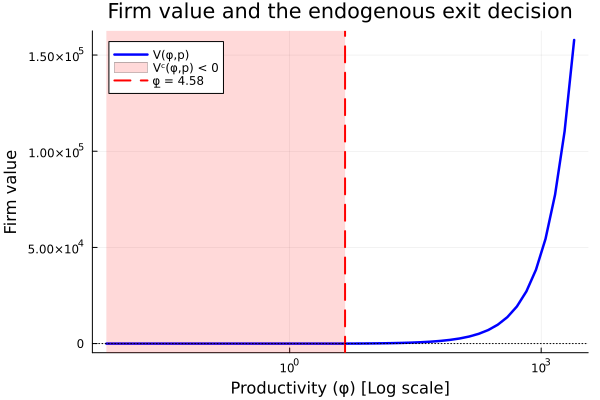

In [15]:
include("scripts/MainPlots.jl")
fnPlotValueFunction(UsedParameters,Endo)

### Comparing distributions: Employment vs. productivity

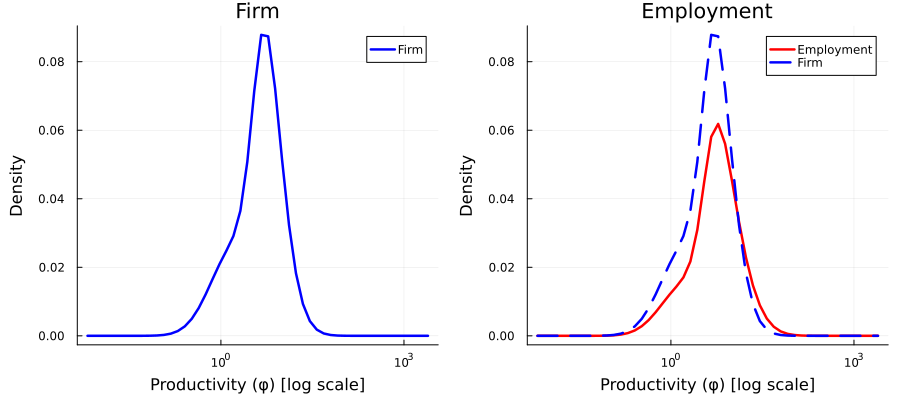

In [25]:
include("scripts/MainPlots.jl")
fnPlotEmploymentVsFirm(UsedParameters,Endo)

- For the firm (productivity) distribution, the peak is located to the left (closer to $10^0$), indicating that the majority of active firms are relatively low-productivity operations.
- Conversely, for the employment distribution, the entire distribution is shifted to the right, with the right tail being much "fatter". This stems from the labour demand function, which scales convexly with its productivity.
- This effectively implies that **more productive firms hire substantially more workers**. 

### Entry and stationary distributions 

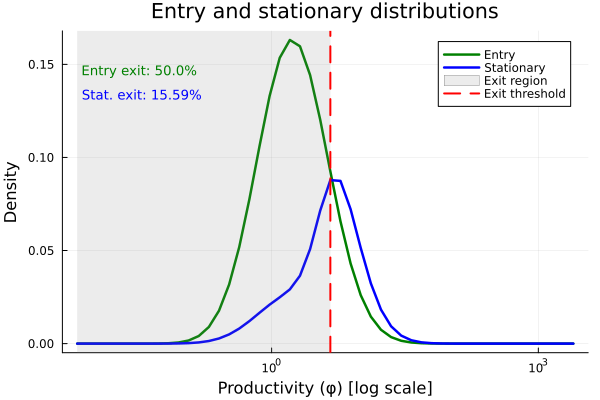

In [34]:
include("scripts/MainPlots.jl")
fnPlotEntryVsStationary(UsedParameters,Endo)

Before thinking about endogenous exit, keep in mind that the x-axis in the log scale, meaning that the area under the curve does not add to $1$. Start with entrants. Notice that many of them will pay $c_e$, produce for one period, and immediately exit towards the end of said period (being below the exit threshold productivity). This means that the surviving entrants' distribution will already be shifted to the right. Then, among incumbents, some will draw an "unlucky" productivity value, placing them below the exit threshold. They will produce for one period, exiting afterwards. These processes keep the stationary distribution to the right of its entry counterpart. This means that the average productivity will be higher for incumbents than for entrants,

### Question 3: Counterfactuals 

In [42]:
include("scripts/Experiments.jl")

Row,Variable,Value,p̂,ER,M̂ᵢ,𝔼n̂,𝔼φ
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,Baseline,0.0,1.48164,0.15588,2.16661,15.385,10.8165
2,c,24.0,1.60787,0.233844,1.7174,19.4092,11.6259
3,cₑ,47.64,1.54049,0.15588,2.04364,16.3107,10.8165
4,D̄,120.0,1.48164,0.15588,2.59993,15.385,10.8165
5,φ̄,3.04043,1.95648,0.15588,2.16661,15.385,8.19131


- **Changes to $c$ and $c_e$ (cost shock)**: In both cases, the firm passes the overhead cost(s) increases to the consumer, raising the price. The increase is larger for the fixed cost, as it is paid every period. At the same time, the exit rate increases more for the entry cost increase, as the less productive firms cannot justify staying in the market. The mass of incumbents drops in both scenarios, as the less productive firms exit the market. In both cases, average firm size increases in response to the elimination of less productive firms. The average size is higher for the fixed cost ($c$), as it must be paid every period. The average productivity does not change when the entry cost increases, as it only impacts the distribution of entrants, which still converges to the same distribution of incumbents.
- **Changes to $\bar{D}$ (demand shock)**: The price does not change, as it's solely determined by $\mathbb{E}V_e = c_e$ (which does not depend on $\bar{D}$). The exit rate and average productivity don't move for a similar reason (they are determined by the firm's optimisation problem, not responding to the aggregate conditions). Perhaps unsurprisingly, the mass of firms increases to satisfy the increased demand.
- **Changes to $\log(\bar{\varphi})$ (productivity shock)**: Less efficient on average, firms need a higher price to cover the costs of the free entry condition. Given that the exit rate is determined by the firm-level optimisation, it doesn't change, meaning that the mass of firms remains the same.  